In [32]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cmocean as cmo
import matplotlib.dates as mdates


# start= pd.to_datetime(ds['time'].values[0], unit='D', origin='julian')



ds = xr.open_dataset("FlocMod_ADV_G_14.nc", decode_times=False)


date = pd.to_datetime("2020-07-16 20:10:01")

print(ds)
# Blank out nans 
ds = ds.dropna(dim="N", how="any")


mtime = [date + pd.Timedelta(t, unit='s') for t in ds.time.values]
nt = len(ds.time) 
Nens = len(ds.N)
volume = ds.Ds**3 * (ds.Ds/10e-6)**ds.nf.isel(time=0) 
print(ds.ssc.values)

# Load in ACDP data
adcp = xr.open_dataset("/global/homes/s/siennaw/scratch/siennaw/data/usgs/resampled_adcp_usgs.nc") #, decode_times=False)
# low, high = 0, 2000
rtime = adcp.time.values #[low:high]
offset= 3.537306921274909
levels = [-100, -80, -50, -20, -1, 0, 1, 20, 50, 80, 100]
adcp_u = np.squeeze(adcp.u_1205)
adcp_z = adcp.depth.values

Ns = len(ds.Ds)

print(ds.Ds*1e6)

def format_date_ax(ax, int=1):
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=int))
    date_format = mdates.DateFormatter('%m/%d %H:%M')
    ax.xaxis.set_major_formatter(date_format)

<xarray.Dataset> Size: 5MB
Dimensions:  (time: 300, Ds: 40, N: 50)
Coordinates:
  * time     (time) float32 1kB 0.0 1.5e+03 3e+03 ... 4.47e+05 4.485e+05
  * Ds       (Ds) float32 160B 1e-05 1.137e-05 1.293e-05 ... 0.001319 0.0015
  * N        (N) float32 200B 1.0 2.0 3.0 4.0 5.0 ... 46.0 47.0 48.0 49.0 50.0
Data variables:
    ssc      (time, Ds, N) float64 5MB ...
    G        (time, N) float64 120kB ...
    nf       (time, N) float64 120kB ...
    alpha    (time, N) float64 120kB ...
    beta     (time, N) float64 120kB ...
    beta2    (time, N) float64 120kB ...
Attributes:
    title:    floc mod test
[[[2.98674800e+02 2.36514697e+02 2.00418036e+03 ... 2.70826099e+02
   1.95384396e+02 1.09225245e+03]
  [1.23156021e+02 1.26839193e+02 1.79639206e+02 ... 1.39325108e+02
   1.29605594e+02 1.21763867e+02]
  [1.60697428e+02 1.63902368e+02 2.12374304e+02 ... 1.75507542e+02
   1.66434389e+02 1.59367047e+02]
  ...
  [4.33986372e-05 6.12539329e-05 1.47569263e-04 ... 2.17227821e-05
   1.368771

<>:9: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:9: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_1494996/1997312440.py:9: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  axs[j].set_title("Ds = %.2f $\mu$m" % (ds.Ds.isel(Ds=Ds).values*1e6))
/tmp/ipykernel_1494996/1997312440.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[-5].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0. )


Text(0.5, 0, 'Time [hr]')

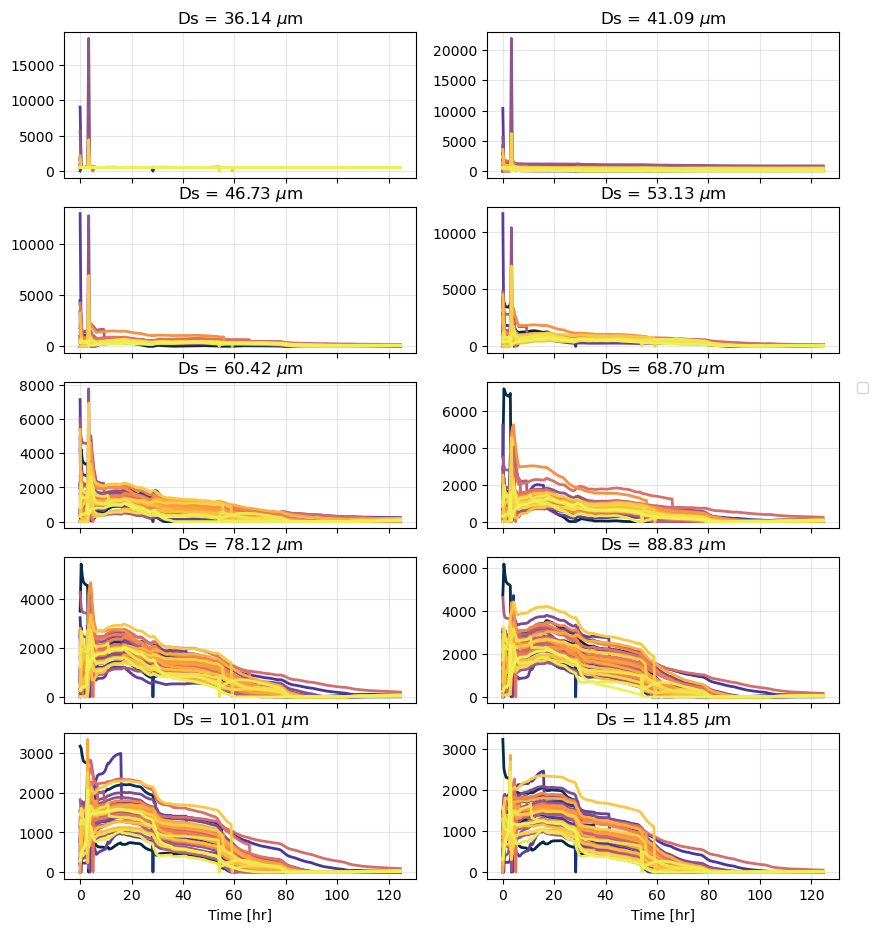

In [33]:
fig, axs = plt.subplots(nrows=5, ncols=2, figsize=(10, 11), sharex=True, sharey=False)
axs = axs.flatten()


for j, Ds in enumerate(range(10, Ns, 1)):
    if j > 9:
        continue
    axs[j].grid(alpha=0.3)
    axs[j].set_title("Ds = %.2f $\mu$m" % (ds.Ds.isel(Ds=Ds).values*1e6))
    time = ds.time.values / 3600
    for i in range(0, Nens):
        G = ds.G.isel(time=1, N=i)
        #ssc       (time, Ds, N)
        # mass = ds.mass.isel(Ds=Ds)
        
        s0 = ds.ssc.isel(N=i).isel(Ds=Ds) #* volume.isel(Ds=Ds, N=i)
        # print(s0)

        axs[j].plot(time, s0, color=cmo.cm.thermal(i/Nens), linewidth=2) #, label="Nens=%d" % i)
        # axs[j].set_ylim(0, 1e4)
axs[-5].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0. )
axs[-1].set_xlabel("Time [hr]")
axs[-2].set_xlabel("Time [hr]")

# fig.savefig("time_evolution_G=%d.png" % (G), dpi=300, bbox_inches='tight')

<>:2: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:3: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:4: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:2: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:3: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:4: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_1494996/1099942376.py:2: SyntaxWarning: "\m" is an invalid escape s

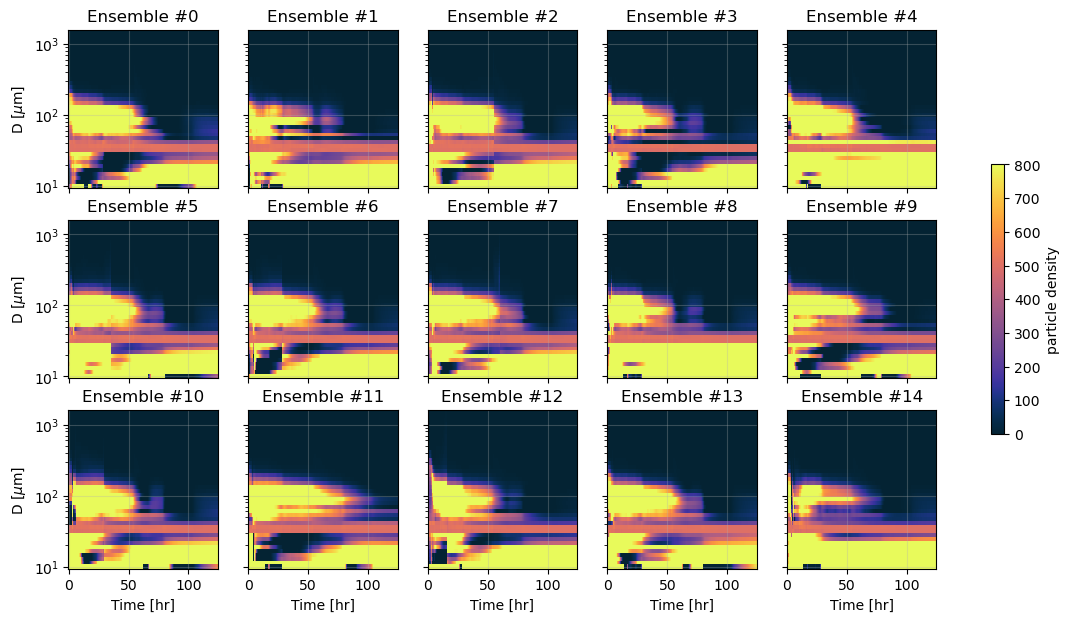

In [34]:
fig, axs = plt.subplots(nrows=3, ncols=5, figsize=(14, 7), sharex=True, sharey=True)
axs[0,0].set_ylabel("D [$\mu$m]")
axs[1,0].set_ylabel("D [$\mu$m]")
axs[2,0].set_ylabel("D [$\mu$m]")

for j in range(5):
    axs[2,j].set_xlabel("Time [hr]")
axs = axs.flatten()


for i in range(0, 15):
    G = ds.G.isel(time=1, N=i)
    axs[i].grid(alpha=0.3)
    axs[i].set_title("Ensemble #%d" % i)
    time = ds.time.values / 3600
    ssc = ds.ssc.isel(N=i) 
    # print(ssc[0:10, 0:5].values)
    h = axs[i].pcolormesh(time, ds.Ds.values*1e6, ssc.T, cmap=cmo.cm.thermal, shading='auto', vmin=0, vmax=0.8e3)
    axs[i].set_yscale("log")
    

plt.colorbar(h, ax=axs, orientation='vertical', label="particle density", shrink=0.5)

# fig.savefig("time-space_G=%d.png" % (G), dpi=300, bbox_inches='tight')

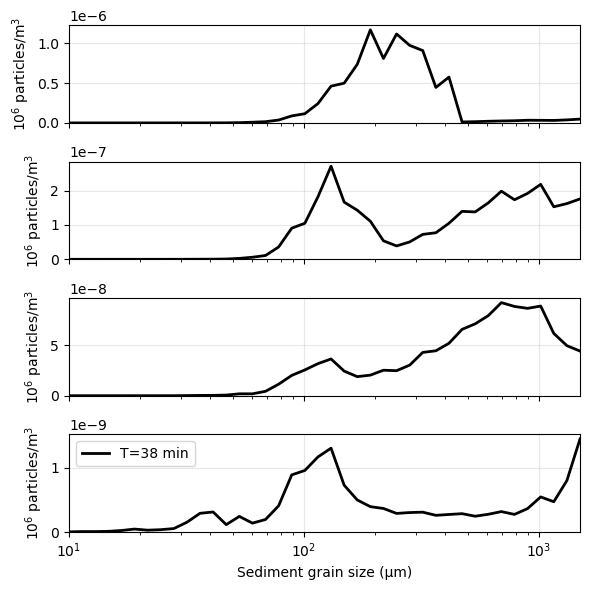

In [35]:
fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(6, 6), sharex=True, sharey=False)


t = 100 

for it, t in enumerate(range(6, nt, nt//4)):
    Ds = ds.Ds.values*1e6
    label="T=%d min" % (t*10/60)
    # for i in range(0, Nens):
    #     var = ds.ssc.isel(time=t, N=i) * volume.isel(N=i)
    #     axs[it].plot(Ds, var, '-', color=cmo.cm.haline(i/Nens), linewidth=2, alpha=0.1) #,color=cmo.cm.thermal(t/nt))

    mean = ds.ssc.isel(time=t).mean(dim="N")* volume.mean(dim="N")
    axs[it].plot(Ds, mean, '-', color='k', linewidth=2, label=label)

    axs[it].set_xscale('log')
    axs[it].grid(alpha=0.3)
    axs[it].set_ylabel("10$^6$ particles/m$^3$")
    axs[it].set_ylim(0,)
    axs[it].set_xlim(Ds[0], Ds[-1])

axs[-1].set_xlabel("Sediment grain size (µm)")
axs[-1].legend()

plt.tight_layout()

# fig.savefig("pdf_G=%d.png" % (G), dpi=300, bbox_inches='tight')

(np.float64(18460.70833912037), np.float64(18465.03125578704))

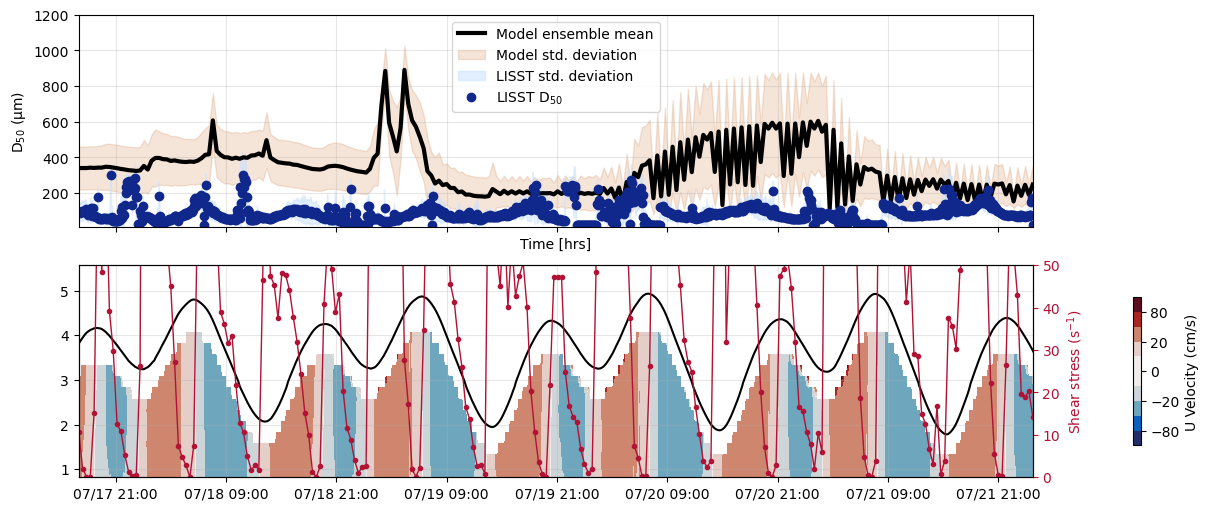

In [36]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(12, 5), sharex=True, sharey=False, constrained_layout=True)

shear = ds.G.isel(N=0) 

var = ds.ssc.mean(dim='N')
weights = var.values + 1e-5
Ds = np.broadcast_to(ds.Ds.values, var.values.shape)
mean_d = np.average(Ds, axis=1, weights=weights)

# hours = ds.time.values / 3600
ax = axs[0]
ax2 = axs[1].twinx()
ax2.plot(mtime, shear, '.-', color='#B21235', linewidth=1, label="Shear stress")
ax2.set_ylim(0,50)
ax2.tick_params(axis='y', colors='#B21235')
ax2.set_ylabel("Shear stress (s$^{-1}$)", color='#B21235')

# stds = lisst['D50'].std(axis=1) 
# std_weight = ds.ssc.std(dim='N')

# print(weights)
# assert(False)
# print(Ds_aligned.shape, weights.shape)
# mean_d = np.average(Ds_aligned, axis=1, weights=weights)


# Number of particles 
var = ds.ssc # shape = (1380, 10, 250)

# Ds = np.broadcast_to(ds.Ds, var) # Ds shape = (10,)
Ds_aligned = ds.Ds.values[None, :, None]


weights = var  *  volume #[None, :, :] 

mean_d = np.sum(Ds_aligned * weights, axis=1) / np.sum(weights, axis=1) 
std_ = mean_d.std(axis=1)


mean_d = np.mean(mean_d, axis=1)
ax.plot(mtime, mean_d*1e6, color='black', linewidth=3, label="Model ensemble mean") 
ax.fill_between(mtime, np.squeeze(mean_d-std_)*1e6, np.squeeze(mean_d+std_)*1e6, color="#CD7A3E", alpha=0.2, label="Model std. deviation")

ax.grid(alpha=0.3)
ax.set_xlabel("Time [hrs]")
ax.set_ylabel("D$_{50}$ (µm)")

ax.set_ylim(10, 1200) 
# ax.set_yscale('log')


fn = "/global/homes/s/siennaw/scratch/siennaw/data/usgs/CSF20_Shallows_Time_Series/CSF20SC104ls-b.nc"
lisst = xr.open_dataset(fn, decode_times=False)
dates = pd.to_datetime(lisst['time'].values, unit='D', origin='julian')
seconds = pd.to_timedelta(lisst['time2'].values, unit='ms')
dates = dates + seconds


d50 = lisst['D50'].isel(depth=0)
stds = lisst['D50'].std(axis=1) 
d50 = lisst['D50'].mean(axis=1)

ax.fill_between(dates, np.squeeze(d50-stds), np.squeeze(d50+stds), color='#CBE2FE', alpha=0.55, label="LISST std. deviation")
ax.plot(dates, d50, 'o', color='#10288C', label="LISST D$_{50}$")
format_date_ax(ax, 12)

# Add ADCP 
h = axs[1].contourf(rtime, -adcp_z + offset, adcp_u.T, cmap=cmo.cm.balance, levels=levels)
plt.colorbar(h, label='U Velocity (cm/s)', shrink=0.7)
axs[1].grid(alpha=0.3)
depths =  np.squeeze(adcp.P_1.values) #+ 0.41
axs[1].plot(rtime, depths, color='k', label='Depth')

axs[0].legend()

ax.set_xlim(mtime[50], mtime[-1])
# ax.set_yscale('log')
# ax.set_title("Shear = %d s$^{-1}$" % G)

# fig.savefig("d50_G=%d.png" % (G), dpi=300, bbox_inches='tight')

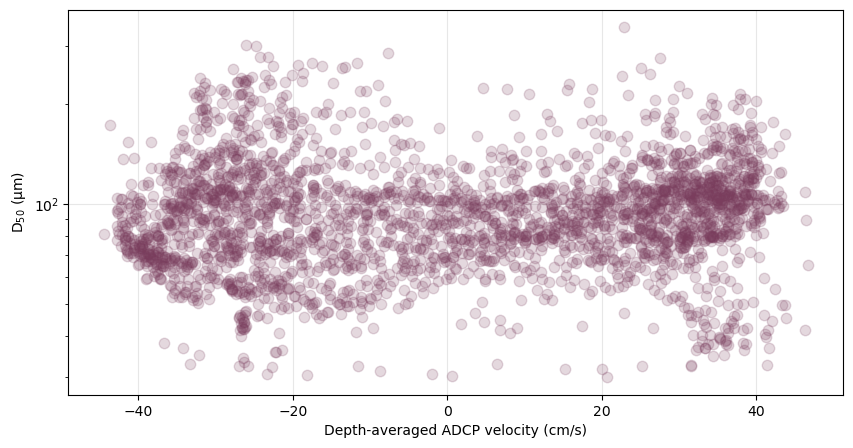

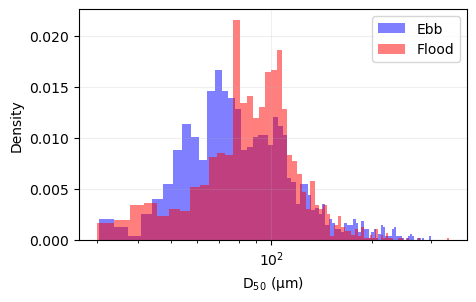

In [37]:

# interpolate LISST data and ACDP data
df_l = pd.Series(np.squeeze(d50), index=dates)
df_v = pd.DataFrame(index=rtime) 
df_v['velocity'] = adcp_u.mean(dim='depth')

# Interpolate df_l on df_v index
df_l_interp = df_l.reindex(df_v.index.union(df_l.index)).interpolate('time').reindex(df_v.index)


df_v['d50'] = df_l_interp
df_v.dropna(inplace=True)
df_v = df_v[df_v['d50'] > 30] # remove negative values

fig = plt.figure(figsize=(10, 5))
ax = plt.gca()

ax.plot(df_v.velocity, df_v.d50, '.', color='#7A3D5D', label="LISST D$_{50}$", alpha=0.2, markersize=15)
ax.set_yscale('log')
ax.set_xlabel("Depth-averaged ADCP velocity (cm/s)")
ax.set_ylabel("D$_{50}$ (µm)")
ax.grid(alpha=0.3)

# Histogram for flood and ebb 
ebb = df_v[df_v.velocity < 0]
flood = df_v[df_v.velocity > 0]
fig = plt.figure(figsize=(5, 3))
ax = plt.gca()
ax.hist(ebb.d50, bins=80, alpha=0.5, label="Ebb", color='b', density=True)
ax.hist(flood.d50, bins=80, alpha=0.5, label="Flood", color='r', density=True)
ax.set_xscale('log')
ax.set_xlabel("D$_{50}$ (µm)")
ax.grid(alpha=0.2)
ax.set_ylabel("Density")
ax.legend()

0.3189218762692708 0.200629267416197
0.04749801763403827 0.200629267416197
1.9020849652992857 0.2684612823414586
0.344887791840839 0.1936681585603913
0.01959932953937605 0.1936681585603913
2.016976941576539 0.22537089709154084
0.3528241861374216 0.19316142566390884
0.011767213969842339 0.19316142566390884
2.027343361768767 0.22195799803124988
0.36135345389367707 0.19256183343198185
0.006997248990427136 0.19256183343198185
2.022282914580328 0.21700573227125833


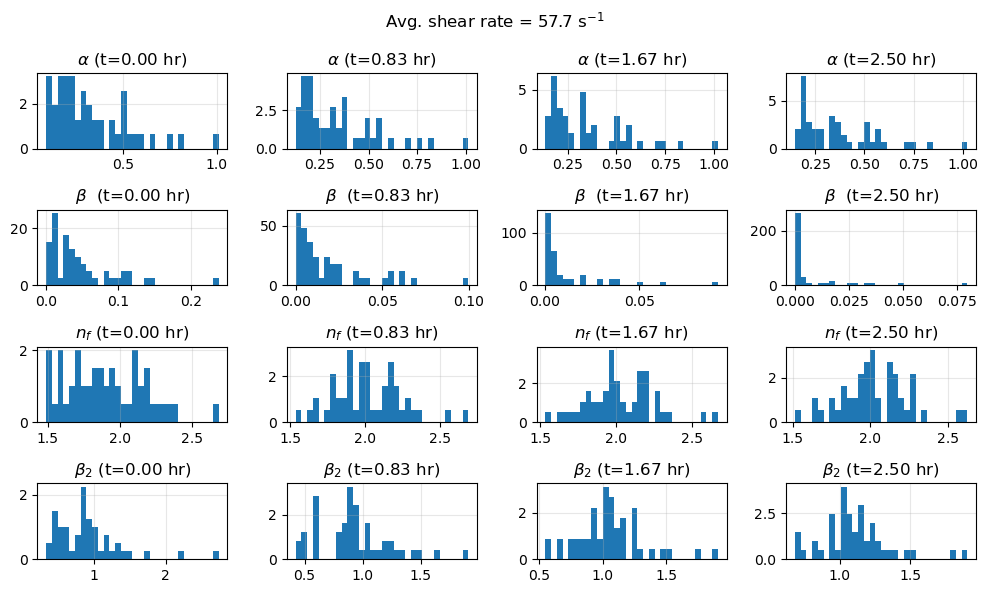

In [38]:
import numpy as np 

fig, axs = plt.subplots(figsize=(10, 6), nrows=4, ncols=4, sharex=False)
shears = ds.G.values.flatten()
shear = np.mean(shears)
plt.suptitle(r"Avg. shear rate = %2.1f s$^{-1}$" % shear) #%.2f hr" % (ds.time.isel(time=i).values/3600))

total = 11
for i, t in enumerate(range(0, total, total//4)):

    if i>3:
        continue
    alphas = ds.alpha.isel(time=t).values
    betas = ds.beta.isel(time=t).values
    nfs = ds.nf.isel(time=t).values
    beta2s = ds.beta2.isel(time=t).values
    axs[0, i].hist(alphas, density=True, bins=30) 
    print(np.mean(alphas), np.std(alphas))
    print(np.mean(betas), np.std(alphas))
    print(np.mean(nfs), np.std(nfs))


    axs[0, i].set_title(r"$\alpha$ (t=%.2f hr)" % (ds.time.isel(time=t).values/3600))
    axs[1, i].hist(betas, density=True, bins=30) 
    axs[1, i].set_title(r"$\beta$  (t=%.2f hr)" % (ds.time.isel(time=t).values/3600))
    axs[2, i].hist(nfs, density=True, bins=30) 
    axs[2, i].set_title("$n_f$ (t=%.2f hr)" % (ds.time.isel(time=t).values/3600))

    axs[3, i].hist(beta2s, density=True, bins=30)
    axs[3, i].set_title(r"$\beta_2$ (t=%.2f hr)" % (ds.time.isel(time=t).values/3600))

for ax in axs.flatten():
    ax.grid(alpha=0.3)
plt.tight_layout()
    # axs[0].set_yscale('log')
    # axs[1].set_yscale('log')
    # axs[2].set_yscale('log')

